In [248]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    GridSearchCV,
    StratifiedKFold,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [249]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x: .3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update(
    {
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)
RANDOM_STATE = 42
CSV_PATH = "../data/Loan_default.csv"
TARGET_COLUMN = "Default"

In [250]:
df = pd.read_csv(CSV_PATH)

In [251]:
df.shape

(255347, 18)

In [252]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.230,36,0.440,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.810,60,0.680,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.170,24,0.310,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.070,24,0.230,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.510,48,0.730,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [253]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')

In [254]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [255]:
print("\nMissing values per column")
print(df.isna().sum())


Missing values per column
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [256]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Column:", num_cols)
print("Categorical Column:", cat_cols)
print("Target Value:", TARGET_COLUMN)

Numerical Column: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']
Categorical Column: ['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
Target Value: Default


/tmp/ipykernel_54248/2181419333.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [257]:
for col in df.columns:
    print(df[col].value_counts().head(10))

LoanID
I38PQUQS96    1
HPSK72WA7R    1
C1OZ6DPJ8Y    1
V2KKSFM3UN    1
EY08JDHTZP    1
A9S62RQ7US    1
H8GXPAOS71    1
0HGZQKJ36W    1
1R0N3LGNRJ    1
CM9L1GTT2P    1
Name: count, dtype: int64
Age
55    5064
40    5056
65    5027
33    5022
53    5010
62    4999
34    4987
45    4985
61    4982
39    4973
Name: count, dtype: int64
Income
121985    10
69492     10
117102    10
149401     9
123299     9
23098      9
77704      9
95094      9
62823      9
118191     9
Name: count, dtype: int64
LoanAmount
221949    8
133724    8
95419     8
183627    7
29290     7
111464    7
189116    7
179176    7
106920    7
202411    7
Name: count, dtype: int64
CreditScore
630    528
445    521
829    520
753    519
670    515
347    514
643    514
775    512
362    510
628    508
Name: count, dtype: int64
MonthsEmployed
56     2227
26     2223
45     2220
107    2207
79     2198
17     2198
118    2196
94     2194
34     2194
28     2190
Name: count, dtype: int64
NumCreditLines
2    64130
3    63834
4

In [258]:
# checking for duplicates

duplicates = df.duplicated().sum()

print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


In [259]:
df[num_cols].describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000,255347.000,255347.000,255347.000,255347.000,255347.000,255347.000,255347.000,255347.000,255347.000
mean,43.498,82499.305,127578.866,574.264,59.542,2.501,13.493,36.026,0.500,0.116
std,14.990,38963.014,70840.706,158.904,34.643,1.117,6.636,16.969,0.231,0.320
min,18.000,15000.000,5000.000,300.000,0.000,1.000,2.000,12.000,0.100,0.000
25%,31.000,48825.500,66156.000,437.000,30.000,2.000,7.770,24.000,0.300,0.000
50%,43.000,82466.000,127556.000,574.000,60.000,2.000,13.460,36.000,0.500,0.000
75%,56.000,116219.000,188985.000,712.000,90.000,3.000,19.250,48.000,0.700,0.000
max,69.000,149999.000,249999.000,849.000,119.000,4.000,25.000,60.000,0.900,1.000


Text(0.5, 1.0, 'Targe distribution')

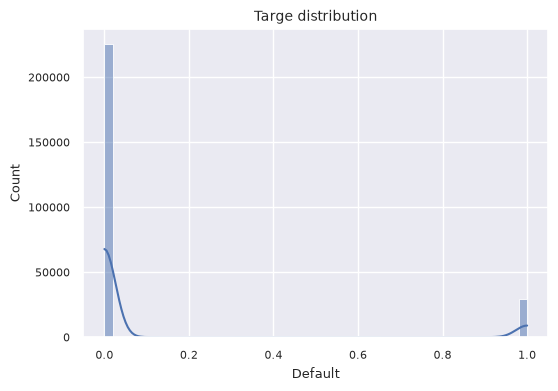

In [260]:
# target column distribution

plt.figure(figsize=(6, 4))
sns.histplot(df[TARGET_COLUMN], bins=50, kde=True)
plt.title("Targe distribution")

In [261]:
df[TARGET_COLUMN].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

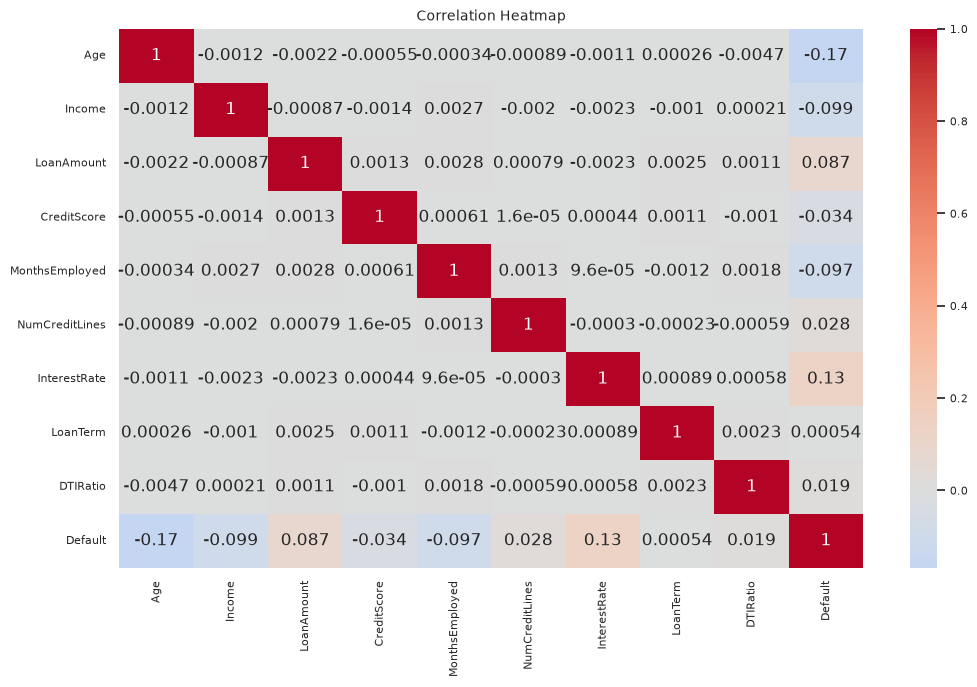

In [262]:
plt.figure(figsize=(12, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap")
plt.show()

In [263]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


LoanID
LoanID
I38PQUQS96    1
HPSK72WA7R    1
C1OZ6DPJ8Y    1
V2KKSFM3UN    1
EY08JDHTZP    1
             ..
8C6S86ESGC    1
98R4KDHNND    1
XQK1UUUNGP    1
JAO28CPL4H    1
ZTH91CGL0B    1
Name: count, Length: 255347, dtype: int64

Education
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

EmploymentType
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

HasMortgage
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

HasDependents
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

LoanPurpose
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

HasCoSigner
HasCoSigner
Yes    127701
No     127646
Name: count, dtyp

In [264]:
df.drop(columns=["LoanID"], inplace=True)

In [265]:
df.shape

(255347, 17)

In [266]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

In [267]:
X.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.230,36,0.440,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes
1,69,50432,124440,458,15,1,4.810,60,0.680,Master's,Full-time,Married,No,No,Other,Yes
2,46,84208,129188,451,26,3,21.170,24,0.310,Master's,Unemployed,Divorced,Yes,Yes,Auto,No
3,32,31713,44799,743,0,3,7.070,24,0.230,High School,Full-time,Married,No,No,Business,No
4,60,20437,9139,633,8,4,6.510,48,0.730,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No


In [268]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [269]:
print("Train data shape", X_train.shape)
print("Test data shape", X_test.shape)

Train data shape (204277, 16)
Test data shape (51070, 16)


# Preprocessing Pipeline


In [270]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(numerical_features)
print(categorical_features)

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer()),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [271]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [272]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [273]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            HistGradientBoostingClassifier(
                class_weight="balanced", random_state=RANDOM_STATE
            ),
        ),
    ]
)

baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Age','Income','LoanAmount',...,'HasDependents','LoanPurpose', 'HasCoSigner']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``,

In [274]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
)

In [275]:
training_baseline_pred = baseline_pipeline.predict(X_train)
test_baseline_pred = baseline_pipeline.predict(X_test)

In [276]:
training_baseline_pred

array([1, 0, 0, ..., 0, 1, 0], shape=(204277,))

In [277]:
test_baseline_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(51070,))

In [278]:
train_baseline_accuracy = accuracy_score(y_train, training_baseline_pred)
train_baseline_precision = precision_score(y_train, training_baseline_pred)
train_baseline_recall = recall_score(y_train, training_baseline_pred)

print("\n--- TRAIN Baseline Metrics (Logistic Regression) ---")
print(f"Accuracy Score:{train_baseline_accuracy:.3f}")
print(f"Precision: {train_baseline_precision:.3f}")
print(f"Recall: {train_baseline_recall:.3f}")
print(f"Classification Report: {classification_report(y_train,training_baseline_pred)}")


--- TRAIN Baseline Metrics (Logistic Regression) ---
Accuracy Score:0.704
Precision: 0.239
Recall: 0.709
Classification Report:               precision    recall  f1-score   support

           0       0.95      0.70      0.81    180555
           1       0.24      0.71      0.36     23722

    accuracy                           0.70    204277
   macro avg       0.59      0.71      0.58    204277
weighted avg       0.87      0.70      0.76    204277



In [279]:
test_baseline_accuracy = accuracy_score(y_test, test_baseline_pred)
test_baseline_precision = precision_score(y_test, test_baseline_pred)
test_baseline_recall = recall_score(y_test, test_baseline_pred)

print("\n--- TEST Baseline Metrics (Logistic Regression) ---")
print(f"Accuracy Score:{test_baseline_accuracy:.3f}")
print(f"Precision: {test_baseline_precision:.3f}")
print(f"Recall: {test_baseline_recall:.3f}")
print(f"Classification Report: {classification_report(y_test,test_baseline_pred)}")


--- TEST Baseline Metrics (Logistic Regression) ---
Accuracy Score:0.695
Precision: 0.228
Recall: 0.682
Classification Report:               precision    recall  f1-score   support

           0       0.94      0.70      0.80     45139
           1       0.23      0.68      0.34      5931

    accuracy                           0.70     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.70      0.75     51070



Model Selection and optimization


In [280]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [281]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [282]:
models = {
    "LogisticRegression": LogisticRegression(),
    "HistGB": HistGradientBoostingClassifier(),
    # "suppportvector": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
    "xgboost": XGBClassifier(),
}

In [283]:
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall"}

In [284]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])

    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append(
        {
            "model": name,
            "accuracy": scores["test_accuracy"].mean(),
            "precision": scores["test_precision"].mean(),
            "recall": scores["test_recall"].mean(),
        }
    )

cv_results = pd.DataFrame(rows).sort_values("accuracy")
print("=== CV Model Comparison ===")
print(cv_results)